# Lab Experiment 5: Linear Regression through Gradient Descent Variants
**Aim:** To implement Linear Regression using Batch, Mini-Batch, and Stochastic Gradient Descent and compare them.

**Dataset:** Student Performance Dataset from UCI Machine Learning Repository.

## Step 1: Import Libraries and Load Dataset
This step initializes the necessary libraries and prepares the dataset, selecting 'G2' as the independent variable and 'G3' as the target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('data/student-mat.csv', sep=';')
df = df.dropna()

# Use only one feature (G2) for easy 2D/3D visualization
X = df[['G2']].values

# Target (G3)
y = df['G3'].values.reshape(-1, 1)

# Scale feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

m = len(X_scaled)

# Add bias column (intercept term)
X_bias = np.c_[np.ones((m, 1)), X_scaled]

print("Shape of X (with bias):", X_bias.shape)
print("Shape of y:", y.shape)

Shape of X (with bias): (395, 2)
Shape of y: (395, 1)


## Step 2: Define the Cost Function
The compute_cost function calculates the Mean Squared Error (MSE), which is used to evaluate the performance of the linear regression model.

In [2]:
def compute_cost(theta, X, y):
    predictions = X.dot(theta)
    return (1 / (2 * len(y))) * np.sum((predictions - y) ** 2)

## Step 3: Implement Batch Gradient Descent (BGD)
Batch Gradient Descent updates the model parameters (theta) using the gradients calculated from all training examples in each iteration.

In [3]:
def batch_gradient_descent(X, y, learning_rate=0.05, epochs=100):
    theta = np.zeros((2, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        predictions = X.dot(theta)
        gradients = (1 / m) * X.T.dot(predictions - y)
        theta = theta - learning_rate * gradients
        history.append(theta.copy())
        cost = compute_cost(theta, X, y)
        cost_history.append(cost)
    return theta, np.array(history), cost_history

## Step 4: Implement Mini-Batch Gradient Descent (MBGD)
Mini-Batch Gradient Descent updates parameters using a small, randomly selected subset of the training data in each iteration.

In [4]:
def mini_batch_gradient_descent(X, y, learning_rate=0.05, epochs=100, batch_size=32):
    theta = np.zeros((2, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            predictions = X_batch.dot(theta)
            gradients = (1 / len(X_batch)) * X_batch.T.dot(predictions - y_batch)
            theta = theta - learning_rate * gradients

        history.append(theta.copy())
        cost = compute_cost(theta, X, y)
        cost_history.append(cost)
    return theta, np.array(history), cost_history

## Step 5: Implement Stochastic Gradient Descent (SGD)
Stochastic Gradient Descent updates parameters using only one randomly chosen training example at a time.

In [5]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    theta = np.zeros((2, 1))
    history = []
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            predictions = xi.dot(theta)
            gradients = xi.T.dot(predictions - yi)
            theta = theta - learning_rate * gradients

        history.append(theta.copy())
        cost = compute_cost(theta, X, y)
        cost_history.append(cost)
    return theta, np.array(history), cost_history

## Step 6: Train All Models
Here, each of the three gradient descent algorithms are called to train the models.

In [6]:
theta_batch, history_batch, cost_batch = batch_gradient_descent(X_bias, y)
theta_mini, history_mini, cost_mini = mini_batch_gradient_descent(X_bias, y)
theta_sgd, history_sgd, cost_sgd = stochastic_gradient_descent(X_bias, y, learning_rate=0.005)

## Step 7: Create the Cost Surface
To visualize the optimization process in 3D, a cost surface is created based on range of theta values.

In [7]:
theta0_vals = np.linspace(-5, 25, 100)
theta1_vals = np.linspace(-5, 25, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_temp = np.array([[T0[i, j]],
                               [T1[i, j]]])
        J_vals[i, j] = compute_cost(theta_temp, X_bias, y)

## Step 8: 3D Visualization of Optimization Paths
This section generates three 3D plots showing the cost surface and the optimization path taken by each algorithm.

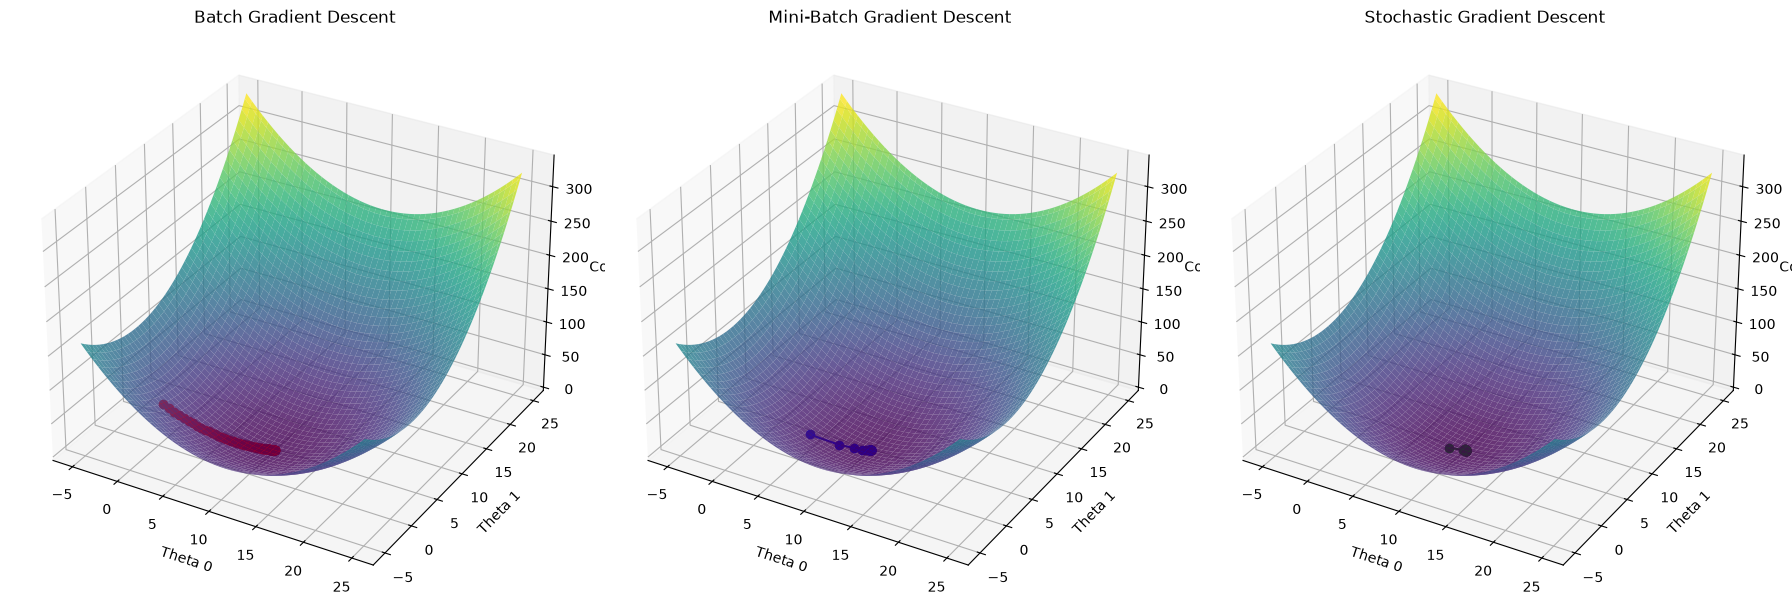

In [8]:
fig = plt.figure(figsize=(18, 6))

# BATCH GD
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax1.plot(history_batch[:, 0].flatten(), history_batch[:, 1].flatten(),
         [compute_cost(h.reshape(2,1), X_bias, y) for h in history_batch],
         color='red', marker='o')
ax1.set_title("Batch Gradient Descent")
ax1.set_xlabel("Theta 0")
ax1.set_ylabel("Theta 1")
ax1.set_zlabel("Cost")

# MINI-BATCH GD
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax2.plot(history_mini[:, 0].flatten(), history_mini[:, 1].flatten(),
         [compute_cost(h.reshape(2,1), X_bias, y) for h in history_mini],
         color='blue', marker='o')
ax2.set_title("Mini-Batch Gradient Descent")
ax2.set_xlabel("Theta 0")
ax2.set_ylabel("Theta 1")
ax2.set_zlabel("Cost")

# SGD
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax3.plot(history_sgd[:, 0].flatten(), history_sgd[:, 1].flatten(),
         [compute_cost(h.reshape(2,1), X_bias, y) for h in history_sgd],
         color='green', marker='o')
ax3.set_title("Stochastic Gradient Descent")
ax3.set_xlabel("Theta 0")
ax3.set_ylabel("Theta 1")
ax3.set_zlabel("Cost")

plt.tight_layout()
plt.show()

## Step 9: Loss Curve Comparison
This plot visualizes the cost (MSE) over epochs for each method.

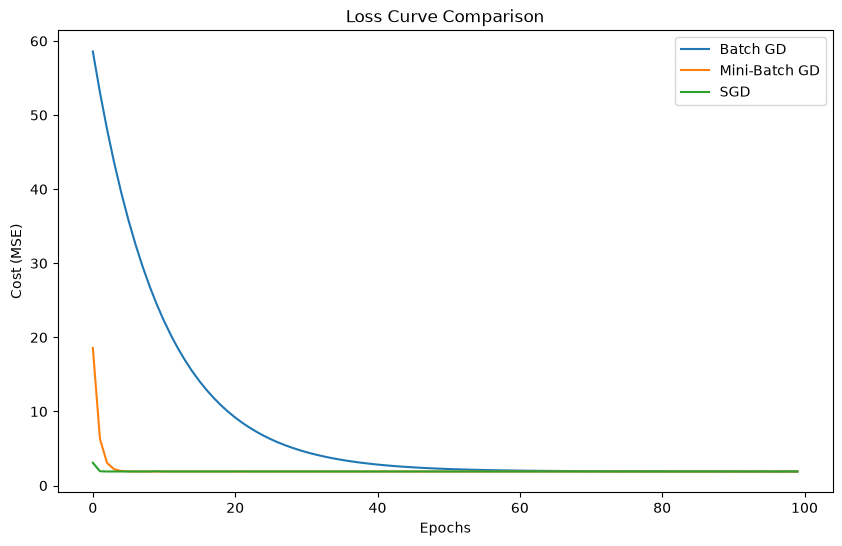

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(cost_batch, label="Batch GD")
plt.plot(cost_mini, label="Mini-Batch GD")
plt.plot(cost_sgd, label="SGD")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Loss Curve Comparison")
plt.legend()
plt.show()

## Step 10: Regression Line Comparison
This plot displays the original data points along with the final regression lines.

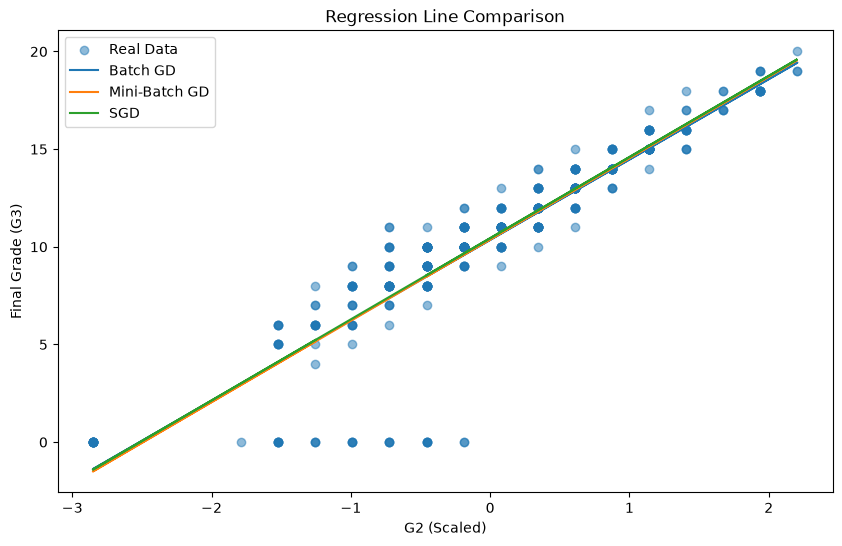

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled, y, alpha=0.5, label="Real Data")

# Batch GD line
plt.plot(X_scaled, X_bias.dot(theta_batch), label="Batch GD")

# Mini-Batch GD line
plt.plot(X_scaled, X_bias.dot(theta_mini), label="Mini-Batch GD")

# SGD line
plt.plot(X_scaled, X_bias.dot(theta_sgd), label="SGD")

plt.xlabel("G2 (Scaled)")
plt.ylabel("Final Grade (G3)")
plt.title("Regression Line Comparison")
plt.legend()
plt.show()

## Step 11: Final Parameters
Prints the optimized theta values (intercept and slope) for each method.

In [11]:
print("\n==============================")
print("FINAL PARAMETERS")
print("==============================")

print("\nBatch GD")
print(theta_batch)

print("\nMini-Batch GD")
print(theta_mini)

print("\nStochastic GD")
print(theta_sgd)


FINAL PARAMETERS

Batch GD
[[10.35352644]
 [ 4.11583678]]

Mini-Batch GD
[[10.37589649]
 [ 4.16584168]]

Stochastic GD
[[10.44173215]
 [ 4.15512882]]
